In [1]:
import os
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))
try:
    from utils import neighbourhood_graph, compute_similarities_1vsAll, compute_distances_1vsAll
except ImportError:
    pass # Adjust if your utils.py is located differently
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import pickle

# Setup your path logic dynamically
product_id = "26008"
metric = "cid"  # Change to 'cid' or other metrics as needed
window_size = 15
step = 1
threshold = "2.03"

# ── Distribution mode configuration ──────────────────────────────────────────
MODE             = "threshold"  # "none" → all edges | "percentile" → top-X%
PERCENTILE       = 0.5           # float: keep top X% most similar / closest
target_edges_only = False        # True → only edges incident on product_id

ENABLE_Z_NORMALIZATION = True # Flag to enable/disable Z-score normalization

# Ensure this path matches where graph_lstm.py saves the pkls
if MODE == "percentile":
    pkl_path = f"DynamicGraphPkls/{product_id}/{metric}/{window_size}/{step}/percentile{PERCENTILE}/dynamic_graphs_{metric}_Window{window_size}_Step{step}_percentile{PERCENTILE}.pkl"
elif MODE == "threshold":
    pkl_path = f"DynamicGraphPkls/{product_id}/{metric}/{window_size}/{step}/th{threshold}/dynamic_graphs_{metric}_Window{window_size}_Step{step}_th{threshold}.pkl"

graphs = []
if os.path.exists(pkl_path):
    print(f"Loading graphs from: {pkl_path}")
    with open(pkl_path, 'rb') as f:
        graphs = pickle.load(f)
    print(f"Successfully loaded {len(graphs)} sliding window graphs.")
else:
    print(f"File not found: {pkl_path}")
    print("Generating them dynamically...")
    
    DATA_PATH = "../../../dataset/data_andre.feather"
    if os.path.exists(DATA_PATH):
        df_raw = pd.read_feather(DATA_PATH)
        cat_labels_dict = df_raw.drop_duplicates('item_id').set_index('item_id')['cat_label'].to_dict()
        df_wide = df_raw.pivot_table(index='item_id', columns='date', values='value', aggfunc='sum').fillna(0)
        
        # Dynamically switch between distance and similarity logic
        distance_metrics = ['cid', 'dtw', 'euclidean', 'manhattan', 'lorentzian', 'amplitude_offset', 'slope_consistency', 'phase_invariance']
        is_distance = metric in distance_metrics
        
        comp_func = compute_distances_1vsAll if is_distance else compute_similarities_1vsAll
        m_type = "distance" if is_distance else "similarity"
        
        if ENABLE_Z_NORMALIZATION:
            print("Applying Z-score normalization...")
            # Replicating the train slice from graph2vec_lstm.py
            L = len(df_wide.columns)
            forecast_horizon_global = 152
            val_size_global = 154
            train_size_global = 455
            global_train_start_idx = max(0, L - forecast_horizon_global - val_size_global - train_size_global)
            global_val_start_idx = L - forecast_horizon_global - val_size_global

            train_df_wide = df_wide.iloc[:, global_train_start_idx:global_val_start_idx]

            # Apply z-normalization identically to graph2vec_lstm.py
            df_wide_scaled = df_wide.copy()
            
            for item_id_iter in df_wide.index:
                z_scaler = StandardScaler()
                # fit on training window for this item
                train_ts = train_df_wide.loc[item_id_iter].values.reshape(-1, 1)
                z_scaler.fit(train_ts)
                
                # Transform the entire continuous history for the graph
                full_ts = df_wide.loc[item_id_iter].values.reshape(-1, 1)
                df_wide_scaled.loc[item_id_iter] = z_scaler.transform(full_ts).flatten()
                
            # Only use scaled dataframe if distance metric AND normalization is enabled
            current_df_wide = df_wide_scaled if is_distance else df_wide
        else:
            print("Z-score normalization is disabled. Using raw values.")
            current_df_wide = df_wide
        
        graphs, global_threshold = neighbourhood_graph(
            product_id=int(product_id),
            metric_type=m_type,
            compute_func=comp_func, 
            df=current_df_wide, 
            metric=metric, 
            window_size=window_size, 
            threshold=float(threshold),
            percentile=None,
            step_size=step, 
            cat_labels=cat_labels_dict,
            plot_dir=None,
            residuals=False,
            enable_edges_within_star=True,
            enable_second_degree=False,  
            num_plots=0
        )
        print(f"Dynamically calculated {len(graphs)} sliding window graphs!")
    else:
        print(f"Could not find DATA_PATH: {DATA_PATH}. Cannot generate graphs dynamically.")

# Restrict graphs list to Train and Validation sets only (removing the test period)
forecast_horizon_global = 153
if len(graphs) > forecast_horizon_global:
    graphs = graphs[:-forecast_horizon_global]
    print(f"Filtered to Train and Validation sets. Remaining graphs: {len(graphs)}")


KeyboardInterrupt: 

In [ ]:
# Make sure we point correctly up 3 levels from GraphAnalysis to Dissertation25-26
DATA_PATH = "../../../dataset/data_andre.feather"

df = pd.DataFrame()
if os.path.exists(DATA_PATH):
    print(f"Loading actual dates from: {DATA_PATH}")
    df = pd.read_feather(DATA_PATH)
    df = df[df['item_id'] == int(product_id)].sort_values('date').reset_index(drop=True)
else:
    print(f"Could not find {DATA_PATH}. Check path strictly!")

if graphs:
    stats = []
    
    # We map the i-th step to the date at the END of the window 
    # (since the first window ends on the window_size-th day)
    for i, g in enumerate(graphs):
        num_nodes = g.number_of_nodes()
        num_edges = g.number_of_edges()
        density = nx.density(g)
        isolates = list(nx.isolates(g))
        
        # Get distances to target product (edges connected to product_id)
        # Note: central product is stored as string/int depending on logic, let's use list(g.nodes)[0] or verify logic.
        target_node = product_id if product_id in g else int(product_id)
        
        distances = []
        if target_node in g:
            for _, _, d in g.edges(target_node, data=True):
                # The weight for star-edges is exactly the raw val_sub computed
                if 'weight' in d:
                    distances.append(d['weight'])
                    
        worst_dist = np.max(distances) if distances else 0.0
        
        # Calculate window end date (the actual day the sliding window prediction/representation corresponds to)
        end_idx = i * step + window_size - 1
        real_date = df['date'].iloc[end_idx] if not df.empty and end_idx < len(df) else i
        
        stats.append({
            'TimeStep': i,
            'Date': real_date,
            'NumNodes': num_nodes,
            'NumEdges': num_edges,
            'Density': density,
            'Isolates': len(isolates),
            'WorstDistance': worst_dist
        })
        
    df_stats = pd.DataFrame(stats)
    if 'Date' in df_stats.columns and not df.empty:
        df_stats['Date'] = pd.to_datetime(df_stats['Date'])
        
    display(df_stats.head())

Loading actual dates from: ../../../dataset/data_andre.feather


,TimeStep,Date,NumNodes,NumEdges,Density,Isolates,WorstDistance
0,0,2021-02-06,2,1,1.000000,0,2.017434
1,1,2021-02-07,1,0,0.000000,1,0.000000
2,2,2021-02-08,2,1,1.000000,0,1.903133
3,3,2021-02-09,4,4,0.666667,0,1.807479
4,4,2021-02-10,4,4,0.666667,0,1.852331


In [ ]:
'''
# ─── Distribution of all edge weights across all windows ──────────────────────
from scipy.stats import gaussian_kde

filter_top_pct    = 0.5    # trim the top X% as visual outliers (keeps X-axis clean)
k_factor          = 1.5    # multiplier for Mean−k·σ and Median−k·MAD reference lines
target_edges_only = False  # True → collect only edges incident on product_id; False → all edges

# ── 1. Collect weights ────────────────────────────────────────────────────────
all_weights = []
if graphs:
    for g in graphs:
        if target_edges_only:
            t_node = product_id if product_id in g else int(product_id)
            if t_node in g:
                for _, _, d in g.edges(t_node, data=True):
                    if 'weight' in d:
                        all_weights.append(d['weight'])
        else:
            for _, _, d in g.edges(data=True):
                if 'weight' in d:
                    all_weights.append(d['weight'])

all_weights = np.array(all_weights)
print(f"Total edges collected across {len(graphs)} windows: {len(all_weights)}")

if len(all_weights) == 0:
    print("No edge weights found in graphs.")
else:
    # ── 2. Clip top-% outliers for cleaner visualisation ─────────────────────
    clip_upper  = np.percentile(all_weights, 100 - filter_top_pct)
    filtered_w  = all_weights[all_weights <= clip_upper]
    n_removed   = len(all_weights) - len(filtered_w)
    print(f"After filtering top {filter_top_pct}%: {len(filtered_w)} edges retained "
          f"({n_removed} removed; upper clip = {clip_upper:.4f})")

    # ── 3. Statistics ─────────────────────────────────────────────────────────
    mean_w      = np.mean(filtered_w)
    median_w    = np.median(filtered_w)
    std_w       = np.std(filtered_w)
    mad_w       = np.median(np.abs(filtered_w - median_w))
    p10_w       = np.percentile(filtered_w, 10)
    mean_kstd   = mean_w   - k_factor * std_w
    median_kmad = median_w - k_factor * mad_w

    # ── 4. Determine axis label ───────────────────────────────────────────────
    distance_metrics = {'cid', 'dtw', 'euclidean', 'manhattan', 'lorentzian',
                        'amplitude_offset', 'slope_consistency', 'phase_invariance'}
    is_dist  = metric in distance_metrics
    xlabel   = f"Distance ({metric})" if is_dist else f"Similarity ({metric})"
    n_items  = (1 if target_edges_only
                else len({n for g in graphs for n in g.nodes()}))
    edge_src = f" | target-node edges only" if target_edges_only else ""
    title    = (f"Filtered (top {filter_top_pct}%) Distribution of Edge {xlabel} "
                f"| window={window_size}, step={step}{edge_src} "
                f"| {n_items} items, {len(filtered_w):,} edges")

    # ── 5. Plot ───────────────────────────────────────────────────────────────
    n_bins = 60
    fig, ax = plt.subplots(figsize=(14, 6))

    # Histogram
    counts, bin_edges, _ = ax.hist(
        filtered_w, bins=n_bins,
        color='steelblue', alpha=0.45, edgecolor='none',
        label='_nolegend_'
    )

    # KDE curve rescaled to match the frequency (count) y-axis
    kde      = gaussian_kde(filtered_w, bw_method='scott')
    x_range  = np.linspace(filtered_w.min(), filtered_w.max(), 600)
    bin_w    = (filtered_w.max() - filtered_w.min()) / n_bins
    ax.plot(x_range, kde(x_range) * len(filtered_w) * bin_w,
            color='steelblue', lw=2.0, alpha=0.85, label='_nolegend_')

    # Reference vertical lines (mirroring the reference image style)
    ax.axvline(mean_w,       color='red',   ls='--', lw=1.8,
               label=f'Mean ({mean_w:.3f})')
    ax.axvline(median_w,     color='navy',  ls='-',  lw=1.8,
               label=f'Median ({median_w:.3f})')
    ax.axvline(mean_kstd,    color='black', ls=':',  lw=1.8,
               label=f'Mean - k*Std ({mean_kstd:.3f})')
    ax.axvline(median_kmad,  color='goldenrod', ls=':', lw=1.8,
               label=f'Median - k*MAD ({median_kmad:.3f})')
    ax.axvline(p10_w,        color='crimson', ls=':', lw=1.8,
               label=f'Percentile 10 ({p10_w:.3f})')

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.legend(loc='upper right', framealpha=0.92, fontsize=10)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()
'''

'\n# ─── Distribution of all edge weights across all windows ──────────────────────\nfrom scipy.stats import gaussian_kde\n\nfilter_top_pct    = 0.5    # trim the top X% as visual outliers (keeps X-axis clean)\nk_factor          = 1.5    # multiplier for Mean−k·σ and Median−k·MAD reference lines\ntarget_edges_only = False  # True → collect only edges incident on product_id; False → all edges\n\n# ── 1. Collect weights ────────────────────────────────────────────────────────\nall_weights = []\nif graphs:\n    for g in graphs:\n        if target_edges_only:\n            t_node = product_id if product_id in g else int(product_id)\n            if t_node in g:\n                for _, _, d in g.edges(t_node, data=True):\n                    if \'weight\' in d:\n                        all_weights.append(d[\'weight\'])\n        else:\n            for _, _, d in g.edges(data=True):\n                if \'weight\' in d:\n                    all_weights.append(d[\'weight\'])\n\nall_weights = np.a

Total edges in graphs across 594 windows: 12,255
No filtering applied: 12,255 edges
  mean=1.7647  median=1.8123  std=0.2105  min=0.4494  max=2.0299


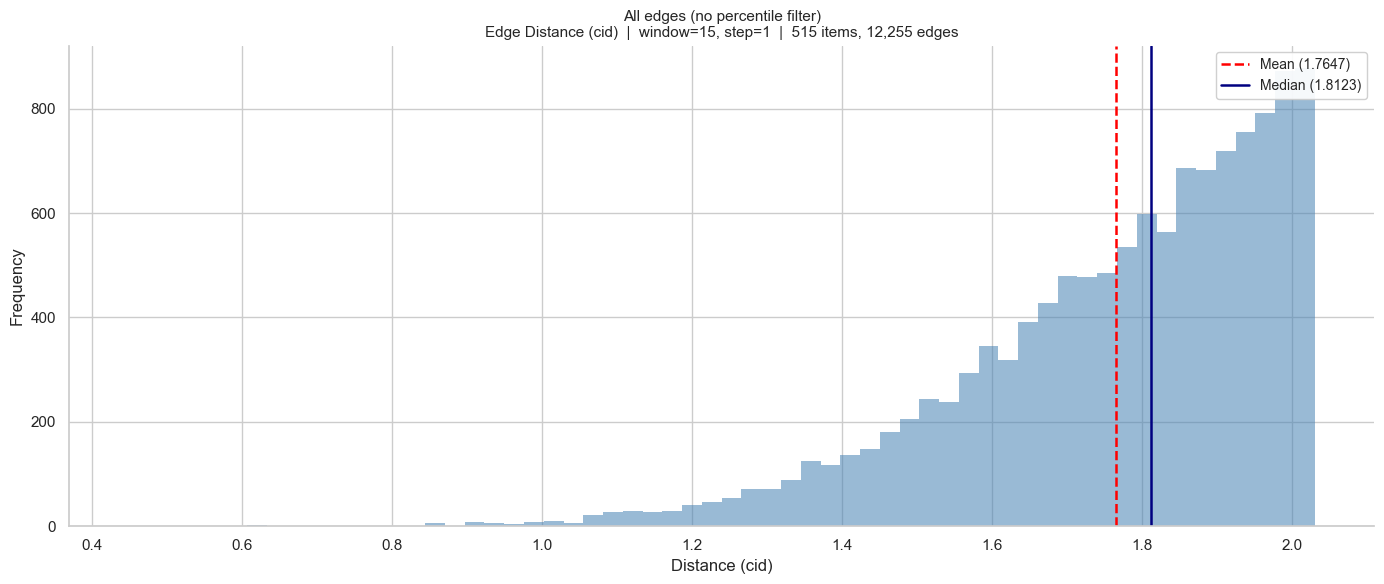

In [ ]:
# Uses MODE, PERCENTILE, target_edges_only defined in cell 2.

distance_metrics = {'cid', 'dtw', 'euclidean', 'manhattan', 'lorentzian',
                    'amplitude_offset', 'slope_consistency', 'phase_invariance'}
is_dist = metric in distance_metrics
comp_fn = compute_distances_1vsAll if is_dist else compute_similarities_1vsAll

# ── 1. Collect ALL raw edge weights from the loaded graphs ────────────────────
all_weights_raw = []
if graphs:
    for g in graphs:
        if target_edges_only:
            t_node = product_id if product_id in g else int(product_id)
            if t_node in g:
                for _, _, d in g.edges(t_node, data=True):
                    if 'weight' in d:
                        all_weights_raw.append(d['weight'])
        else:
            for _, _, d in g.edges(data=True):
                if 'weight' in d:
                    all_weights_raw.append(d['weight'])

all_weights_raw = np.array(all_weights_raw)
print(f"Total edges in graphs across {len(graphs)} windows: {len(all_weights_raw):,}")

if len(all_weights_raw) == 0:
    print("No edge weights found in graphs.")
else:
    # ── 2. Derive percentile cutoff from the FULL unfiltered distribution ─────
    # The graphs were built with a fixed threshold, so all_weights_raw is already
    # truncated. To get a fair percentile we recompute all 1-vs-all pairs for
    # the target product across every window – no threshold applied (mirrors
    # graph_overall.py collect_edge_weights with mode='none').
    if MODE == "percentile":
        pid_int = int(product_id)

        # Use the (possibly z-normalised) wide df that is already in memory;
        # fall back to reloading the raw feather if it was never created
        # (e.g. graphs loaded from pkl without running the dynamic branch).
        if 'current_df_wide' in vars() and current_df_wide is not None:
            df_pct = current_df_wide
        else:
            print("current_df_wide not found – reloading from feather...")
            _df_raw = pd.read_feather("../../../dataset/data_andre.feather")
            df_pct  = _df_raw.pivot_table(
                index='item_id', columns='date', values='value', aggfunc='sum'
            ).fillna(0)

        all_candidates = []
        for i in range(len(graphs)):
            start_idx   = i * step
            end_idx     = start_idx + window_size
            window_data = df_pct.iloc[:, start_idx:end_idx]
            if pid_int not in window_data.index:
                continue
            target_ts = window_data.loc[pid_int].values
            if np.sum(np.abs(target_ts)) == 0:
                continue
            all_ts  = window_data.values
            ids     = window_data.index.values
            vals    = comp_fn(target_ts, all_ts, metric=metric)
            active  = np.sum(np.abs(all_ts), axis=1) > 0
            valid   = (ids != pid_int) & active
            v       = vals[valid]
            all_candidates.append(v[np.isfinite(v)])

        all_candidates = (np.concatenate(all_candidates)
                          if all_candidates else np.array([], dtype=float))
        print(f"All-pairs candidates (no threshold): {len(all_candidates):,}")

        if len(all_candidates) == 0:
            print("[WARN] No candidates; falling back to graph weights for percentile.")
            all_candidates = all_weights_raw

        # Compute the cutoff on the FULL unfiltered distribution
        if is_dist:
            cutoff     = np.percentile(all_candidates, float(PERCENTILE))
            filtered_w = all_weights_raw[all_weights_raw <= cutoff]
            mode_label = f"Top {PERCENTILE}% closest  (distance ≤ {cutoff:.4f})"
        else:
            cutoff     = np.percentile(all_candidates, 100 - float(PERCENTILE))
            filtered_w = all_weights_raw[all_weights_raw >= cutoff]
            mode_label = f"Top {PERCENTILE}% most similar  (similarity ≥ {cutoff:.4f})"

        n_removed = len(all_weights_raw) - len(filtered_w)
        print(f"{mode_label}")
        print(f"  Retained: {len(filtered_w):,}  |  Removed: {n_removed:,}  |  Cutoff: {cutoff:.6f}")
    else:
        filtered_w = all_weights_raw
        cutoff     = None
        mode_label = "All edges (no percentile filter)"
        print(f"No filtering applied: {len(filtered_w):,} edges")

    # ── 3. Statistics ─────────────────────────────────────────────────────────
    mean_w   = np.mean(filtered_w)
    median_w = np.median(filtered_w)
    std_w    = np.std(filtered_w)
    print(f"  mean={mean_w:.4f}  median={median_w:.4f}  std={std_w:.4f}"
          f"  min={filtered_w.min():.4f}  max={filtered_w.max():.4f}")

    # ── 4. Build plot labels ──────────────────────────────────────────────────
    xlabel  = f"Distance ({metric})" if is_dist else f"Similarity ({metric})"
    n_items = (1 if target_edges_only
               else len({n for g in graphs for n in g.nodes()}))
    edge_src = " | target-node edges only" if target_edges_only else ""
    title = (f"{mode_label}\n"
             f"Edge {xlabel}  |  window={window_size}, step={step}{edge_src}"
             f"  |  {n_items} items, {len(filtered_w):,} edges")

    # ── 5. Plot ───────────────────────────────────────────────────────────────
    n_bins = 60
    fig, ax = plt.subplots(figsize=(14, 6))

    ax.hist(filtered_w, bins=n_bins, color='steelblue', alpha=0.55, edgecolor='none')

    ax.axvline(mean_w,   color='red',   ls='--', lw=1.8, label=f'Mean ({mean_w:.4f})')
    ax.axvline(median_w, color='navy',  ls='-',  lw=1.8, label=f'Median ({median_w:.4f})')
    if cutoff is not None:
        lbl = f'{"Max distance" if is_dist else "Min similarity"} cutoff ({cutoff:.4f})'
        ax.axvline(cutoff, color='black', ls=':', lw=2.0, label=lbl)

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.legend(loc='upper right', framealpha=0.92, fontsize=10)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()


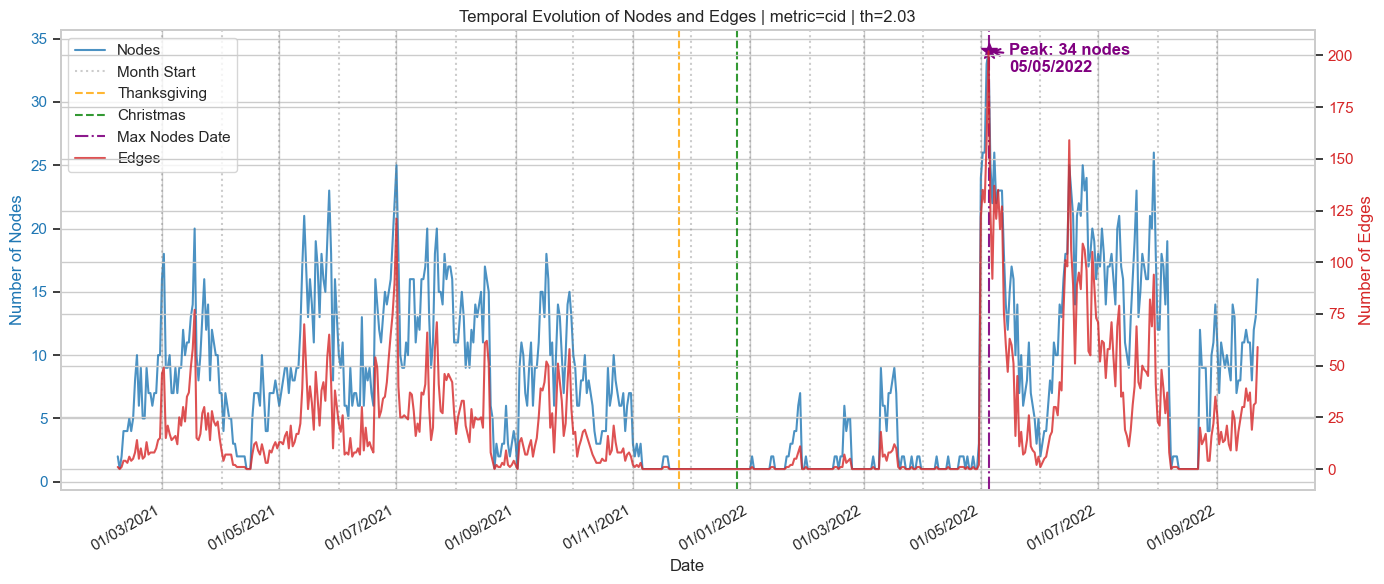

In [ ]:
import matplotlib.dates as mdates

if graphs:
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    color = 'tab:blue'
    x_col = 'Date' if 'Date' in df_stats.columns else 'TimeStep'
    
    # Ensure datetime format for exact plotting
    if x_col == 'Date':
        df_stats['Date'] = pd.to_datetime(df_stats['Date'])
    
    ax1.set_xlabel('Date' if x_col == 'Date' else 'Window Step (Time)')
    ax1.set_ylabel('Number of Nodes', color=color)
    ax1.plot(df_stats[x_col], df_stats['NumNodes'], color=color, alpha=0.8, label='Nodes')
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Create a second y-axis to share the same x-axis
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Number of Edges', color=color)
    ax2.plot(df_stats[x_col], df_stats['NumEdges'], color=color, alpha=0.8, label='Edges')
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Force real date formatting on the x-axis and highlight features
    if x_col == 'Date':
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
        fig.autofmt_xdate()
        
        added_christmas_label = False
        added_month_label = False
        added_thanksgiving_label = False
        
        # Iterate over unique dates to place vertical lines
        for d in df_stats['Date'].dt.date.unique():
            d_obj = pd.to_datetime(d)
            if d_obj.day == 25 and d_obj.month == 12:
                # Highlight Christmas
                ax1.axvline(d_obj, color='green', linestyle='--', alpha=0.8, 
                            label='Christmas' if not added_christmas_label else "")
                added_christmas_label = True
            elif d_obj.month == 11 and d_obj.weekday() == 3 and 22 <= d_obj.day <= 28:
                # Highlight Thanksgiving (4th Thursday of November)
                ax1.axvline(d_obj, color='orange', linestyle='--', alpha=0.8, 
                            label='Thanksgiving' if not added_thanksgiving_label else "")
                added_thanksgiving_label = True
            elif d_obj.day == 1:
                # Highlight Month Beginnings
                ax1.axvline(d_obj, color='gray', linestyle=':', alpha=0.4, 
                            label='Month Start' if not added_month_label else "")
                added_month_label = True
                
        # Highlight Max Nodes Date
        max_idx = df_stats['NumNodes'].idxmax()
        max_date = df_stats.iloc[max_idx][x_col]
        max_nodes = df_stats.iloc[max_idx]['NumNodes']
        
        ax1.axvline(max_date, color='purple', linestyle='-.', alpha=0.9, label='Max Nodes Date')
        ax1.plot(max_date, max_nodes, marker='*', markersize=12, color='purple')
        
        # Add a text annotation pointing to the max peak
        ax1.annotate(f'Peak: {int(max_nodes)} nodes\n{max_date.strftime("%d/%m/%Y")}', 
                     xy=(max_date, max_nodes),
                     xytext=(15, -15), textcoords='offset points', 
                     color='purple', fontweight='bold',
                     arrowprops=dict(arrowstyle="->", color='purple', lw=1.5))
                
        # Consolidate legends from both axes and lines securely
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    if MODE == "percentile" and 'cutoff' in vars() and cutoff is not None:
        _filter_tag = f"percentile={PERCENTILE}%  →  derived th={cutoff:.4f}"
    else:
        _filter_tag = f"th={threshold}"
    plt.title(f'Temporal Evolution of Nodes and Edges | metric={metric} | {_filter_tag}')
    fig.tight_layout()
    plt.show()


In [ ]:
'''
import sys
sys.path.append(os.path.abspath('.'))
from graph_plot import plot_networkx_plotly

if graphs:
    # Use the respective GraphPlots directory to match your project structure
    plots_dir = f"GraphPlots/window_{window_size}/step_{step}/item_{product_id}/{metric}/th{threshold}"
    os.makedirs(plots_dir, exist_ok=True)
    
    skipped_count = 0
    for i, g in enumerate(graphs):
        save_path = os.path.join(plots_dir, f"graph_window_{i}.html")
        
        # Check if the plot already exists to avoid redundant building
        if os.path.exists(save_path):
            skipped_count += 1
            continue
            
        title = f"Graph Window {i} | item={product_id} | {metric} th={threshold}"
        
        # We pass target_node=int(product_id) to highlight the main item in red
        plot_networkx_plotly(g, title=title, save_path=save_path, target_node=int(product_id))
        print(f"Saved interactive plot for window {i} at: {save_path}")
        
    if skipped_count > 0:
        print(f"Skipped {skipped_count} graph plots because they already exist at: {plots_dir}")
        '''

'\nimport sys\nsys.path.append(os.path.abspath(\'.\'))\nfrom graph_plot import plot_networkx_plotly\n\nif graphs:\n    # Use the respective GraphPlots directory to match your project structure\n    plots_dir = f"GraphPlots/window_{window_size}/step_{step}/item_{product_id}/{metric}/th{threshold}"\n    os.makedirs(plots_dir, exist_ok=True)\n\n    skipped_count = 0\n    for i, g in enumerate(graphs):\n        save_path = os.path.join(plots_dir, f"graph_window_{i}.html")\n\n        # Check if the plot already exists to avoid redundant building\n        if os.path.exists(save_path):\n            skipped_count += 1\n            continue\n\n        title = f"Graph Window {i} | item={product_id} | {metric} th={threshold}"\n\n        # We pass target_node=int(product_id) to highlight the main item in red\n        plot_networkx_plotly(g, title=title, save_path=save_path, target_node=int(product_id))\n        print(f"Saved interactive plot for window {i} at: {save_path}")\n\n    if skipped_count